In [1]:
import jax.numpy as jnp
import jax
from jax import Array
from jax.scipy.linalg import inv
import matplotlib.pyplot as plt

from pyutils.jax.dsolve import BKModel, KleinModel
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

## The model

Gali Wage rigidity

$$A_0^w x_t=A_1^wE_t[x_{t+1}]+B_0^wu_t$$

$$x_t=[\tilde y_t, \pi_t^p, \pi_t^w,\tilde\omega_{t-1}]$$

In [2]:
sigma = 1
phi_y = 0.5
phi_p = 1.5
phi_w = 5
varkappa_p = 0.3
varkappa_w = 0.2
beta = 0.99
lambda_p = 0.25
lambda_w = 0.25

A_0w = jnp.array([[sigma+phi_y, phi_p, phi_w,0],
                  [-varkappa_p, 1, 0,0],
                  [-varkappa_w, 0, 1,0],
                  [0,-1,1,1]])

A_1w = jnp.array([[sigma, 1, 0,0],
                  [0, beta,0, lambda_p],
                  [0,0,beta,-lambda_w],
                  [0,0,0,1]])

B_0w = jnp.array([[1,0],
                  [0,0],
                  [0,0],
                  [0,1]])

## Klein

$$AE[x_{t+1}] = B x_t + C z_t$$

In [3]:
klein_model = KleinModel(-A_1w, -A_0w, B_0w, n=1)
z = jnp.zeros((2,20))
z = z.at[0,13].set(0.01)
klein_path = klein_model.solve_path(k0 = jnp.array([0.]), z = z)

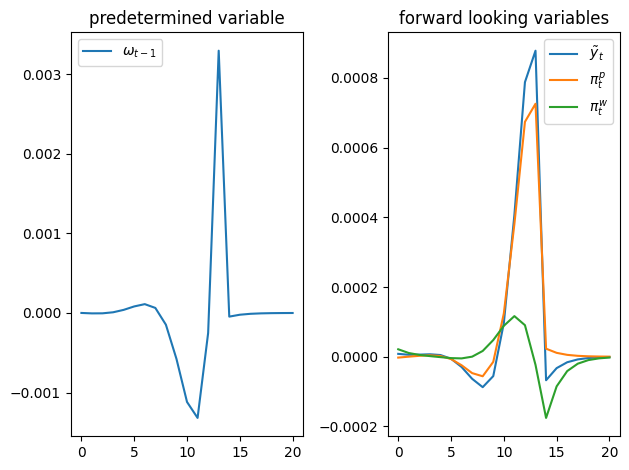

In [4]:
fig, ax = plt.subplots(ncols=2)
ax[0].plot(klein_path["k"].T)
ax[0].legend([r"$\omega_{t-1}$"])
ax[0].set(title="predetermined variable")
ax[1].plot(klein_path["d"].T)
ax[1].legend([r"$\tilde y_t$", r"$\pi_t^p$", r"$\pi_t^w$"])
ax[1].set(title="forward looking variables")
plt.tight_layout()
plt.show()
#plt.plot(solution["d"])

## Blanchard Khan

$$\begin{bmatrix}X_{t+1}\\ _tP_{t+1}\end{bmatrix}=A\begin{bmatrix}X_{t}\\ P_{t}\end{bmatrix}+\gamma Z_t$$

In [5]:
bk_model = BKModel(jnp.linalg.inv(A_1w) @ A_0w, -jnp.linalg.inv(A_1w) @ B_0w, n=1)
bk_path = bk_model.solve_path(x0 = jnp.array([0.]), z = z)

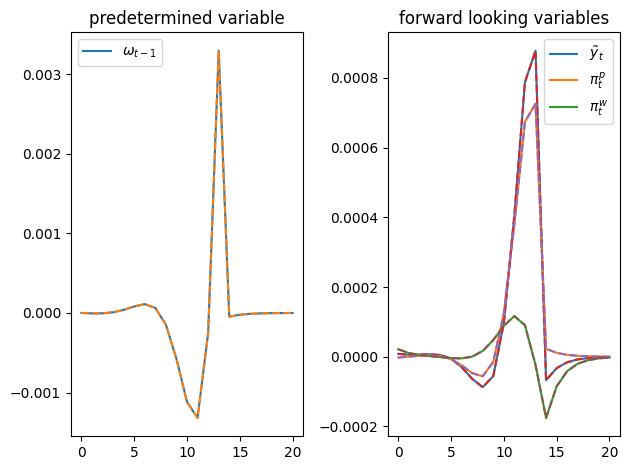

In [6]:
fig, ax = plt.subplots(ncols=2)
ax[0].plot(bk_path["x"].T)
ax[0].plot(klein_path["k"].T, ls='--')
ax[0].legend([r"$\omega_{t-1}$"])
ax[0].set(title="predetermined variable")
ax[1].plot(bk_path["p"].T)
ax[1].plot(klein_path["d"].T, ls='--')
ax[1].legend([r"$\tilde y_t$", r"$\pi_t^p$", r"$\pi_t^w$"])
ax[1].set(title="forward looking variables")
plt.tight_layout()
plt.show()